<a href="https://colab.research.google.com/github/Jake0925/DeepLearning/blob/master/%EA%B2%BD%EC%82%AC%ED%95%98%EA%B0%95%EB%B2%95_%EC%97%AC%EB%9F%AC%EB%B3%80%EC%88%98%EB%A5%BC_%EC%9E%85%EB%A0%A5%ED%95%98%EB%8A%94%EA%B2%BD%EC%9A%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/deeplearningzerotoall/TensorFlow/blob/master/tf_2.x/lab-04-1-Multi-variable-Linear-Regression--Regression-eager.ipynb

다섯사람이 세과목에 대한 시험을 본경우


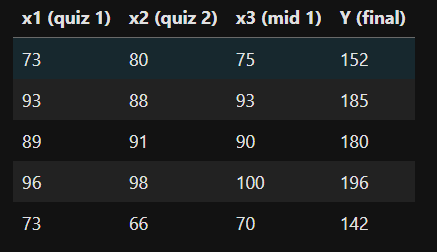

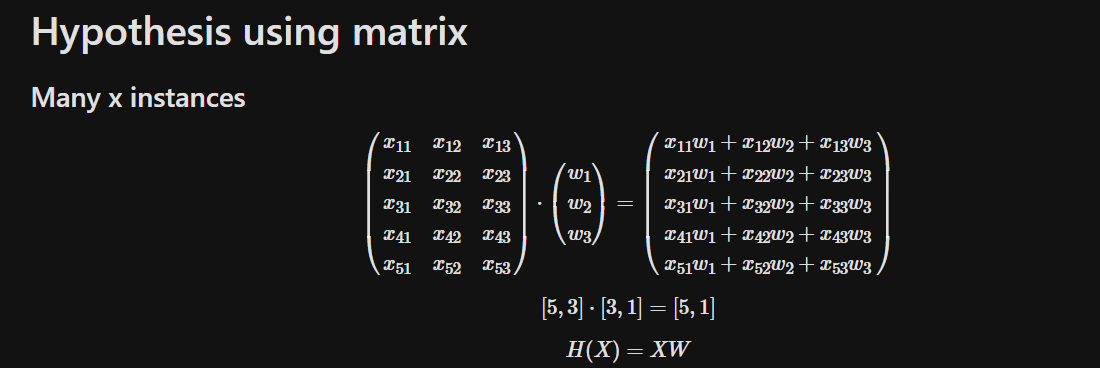

In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)

2.18.0


방법1)

In [2]:
# 입력데이터
x1 = [ 73.,  93.,  89.,  96.,  73.]
x2 = [ 80.,  88.,  91.,  98.,  66.]
x3 = [ 75.,  93.,  90., 100.,  70.]
Y  = [152., 185., 180., 196., 142.]

# 임의로 가중치를 모두 1로 대입함
w1 = tf.Variable(tf.random.normal((1,)))
w2 = tf.Variable(tf.random.normal((1,)))
w3 = tf.Variable(tf.random.normal((1,)))
b  = tf.Variable(tf.random.normal((1,)))

learning_rate = 0.000001

for i in range(1000+1):
    # tf.GradientTape() to record the gradient of the cost function
    with tf.GradientTape() as tape:
        hypothesis = w1 * x1 +  w2 * x2 + w3 * x3 + b # w1x1 + w2x2 + w3x3 +b
        cost = tf.reduce_mean(tf.square(hypothesis - Y)) # 비용함수(실제값과 예측값의 차의 평균)

    w1_grad, w2_grad, w3_grad, b_grad = tape.gradient(cost, [w1, w2, w3, b]) # 미분값(기울기값) 계산

    # w1,w2,w3 and b값 업데이트
    w1.assign_sub(learning_rate * w1_grad)
    w2.assign_sub(learning_rate * w2_grad)
    w3.assign_sub(learning_rate * w3_grad)
    b.assign_sub(learning_rate * b_grad)

    if i % 50 == 0:
      print("{:5} | {:12.4f}".format(i, cost.numpy()))

    0 |  119633.8281
   50 |    1329.8942
  100 |      17.1884
  150 |       2.6213
  200 |       2.4583
  250 |       2.4551
  300 |       2.4536
  350 |       2.4523
  400 |       2.4509
  450 |       2.4495
  500 |       2.4481
  550 |       2.4467
  600 |       2.4453
  650 |       2.4440
  700 |       2.4426
  750 |       2.4413
  800 |       2.4399
  850 |       2.4385
  900 |       2.4372
  950 |       2.4358
 1000 |       2.4345


방법2)

In [3]:
data = np.array([
    # X1,   X2,    X3,   y
    [ 73.,  80.,  75., 152. ],
    [ 93.,  88.,  93., 185. ],
    [ 89.,  91.,  90., 180. ],
    [ 96.,  98., 100., 196. ],
    [ 73.,  66.,  70., 142. ]
], dtype=np.float32)

# slice data
X = data[:, :-1]  # 모든행, 마직막열 제외
y = data[:, [-1]] # 모든행, 마지막열만

W = tf.Variable(tf.random.normal((3, 1))) # 랜덤한 3 * 1 형태의 배열
b = tf.Variable(tf.random.normal((1,)))   # 랜덤한 하나의 값

learning_rate = 0.000001

# hypothesis, prediction function
def predict(X):
    return tf.matmul(X, W) + b

print("epoch | cost")

n_epochs = 2000
for i in range(n_epochs+1):
    # tf.GradientTape() to record the gradient of the cost function
    with tf.GradientTape() as tape:
        cost = tf.reduce_mean((tf.square(predict(X) - y)))

    # calculates the gradients of the loss
    W_grad, b_grad = tape.gradient(cost, [W, b])

    # updates parameters (W and b)
    W.assign_sub(learning_rate * W_grad)
    b.assign_sub(learning_rate * b_grad)

    if i % 100 == 0:
        print("{:5} | {:10.4f}".format(i, cost.numpy()))

epoch | cost
    0 |  7088.6680
  100 |     2.4109
  200 |     1.5307
  300 |     1.5230
  400 |     1.5154
  500 |     1.5078
  600 |     1.5003
  700 |     1.4929
  800 |     1.4854
  900 |     1.4780
 1000 |     1.4706
 1100 |     1.4633
 1200 |     1.4560
 1300 |     1.4488
 1400 |     1.4416
 1500 |     1.4344
 1600 |     1.4273
 1700 |     1.4202
 1800 |     1.4132
 1900 |     1.4061
 2000 |     1.3992


In [4]:
W.numpy()

array([[1.0619943 ],
       [0.20407775],
       [0.7123364 ]], dtype=float32)

In [5]:
b.numpy()

array([2.7099206], dtype=float32)

최종 예측값 결과
- 얘측된 w,b값에 입력값을 대입한 결과

In [6]:
tf.matmul(X, W) + b

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[149.98695],
       [185.6815 ],
       [179.90877],
       [195.89464],
       [143.56818]], dtype=float32)>

In [7]:
tf.random.set_seed(0)  # for reproducibility

예제 1

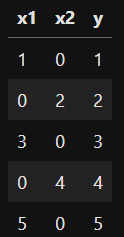

In [8]:
x1_data = [1, 0, 3, 0, 5]
x2_data = [0, 2, 0, 4, 0]
y_data  = [1, 2, 3, 4, 5]


# -10~10안에 임의의 1개의값 대입
W1 = tf.Variable(tf.random.uniform((1,), -10.0, 10.0))
W2 = tf.Variable(tf.random.uniform((1,), -10.0, 10.0))
b  = tf.Variable(tf.random.uniform((1,), -10.0, 10.0))

learning_rate = tf.Variable(0.001)

for i in range(1000+1):
    with tf.GradientTape() as tape:
        hypothesis = W1 * x1_data + W2 * x2_data + b
        cost = tf.reduce_mean(tf.square(hypothesis - y_data))
    W1_grad, W2_grad, b_grad = tape.gradient(cost, [W1, W2, b])
    W1.assign_sub(learning_rate * W1_grad)
    W2.assign_sub(learning_rate * W2_grad)
    b.assign_sub(learning_rate * b_grad)

    if i % 50 == 0:
        print("{:5} | {:10.6f} | {:10.4f} | {:10.4f} | {:10.6f}".format(
          i, cost.numpy(), W1.numpy()[0], W2.numpy()[0], b.numpy()[0]))

    0 | 335.280823 |    -4.0663 |     1.1220 |  -6.065215
   50 |  76.037262 |    -0.8001 |     1.6209 |  -4.978779
  100 |  18.959263 |     0.7151 |     1.8781 |  -4.429109
  150 |   6.310240 |     1.4125 |     2.0104 |  -4.134423
  200 |   3.445082 |     1.7284 |     2.0768 |  -3.961648
  250 |   2.743659 |     1.8667 |     2.1075 |  -3.847750
  300 |   2.525401 |     1.9225 |     2.1184 |  -3.762738
  350 |   2.417754 |     1.9402 |     2.1181 |  -3.692262
  400 |   2.337300 |     1.9403 |     2.1114 |  -3.629400
  450 |   2.264998 |     1.9325 |     2.1008 |  -3.570778
  500 |   2.196328 |     1.9213 |     2.0881 |  -3.514729
  550 |   2.130126 |     1.9085 |     2.0741 |  -3.460409
  600 |   2.066037 |     1.8953 |     2.0595 |  -3.407385
  650 |   2.003917 |     1.8819 |     2.0444 |  -3.355424
  700 |   1.943679 |     1.8686 |     2.0293 |  -3.304398
  750 |   1.885258 |     1.8555 |     2.0141 |  -3.254230
  800 |   1.828595 |     1.8425 |     1.9990 |  -3.204873
  850 |   1.77

예제 2

In [9]:
x_data = [
    [1., 0., 3., 0., 5.],
    [0., 2., 0., 4., 0.]
]
y_data  = [1, 2, 3, 4, 5]

W = tf.Variable(tf.random.uniform((1, 2), -1.0, 1.0))
b = tf.Variable(tf.random.uniform((1,), -1.0, 1.0))

learning_rate = tf.Variable(0.001)

for i in range(1000+1):
    with tf.GradientTape() as tape:
        hypothesis = tf.matmul(W, x_data) + b # (1, 2) * (2, 5) = (1, 5)
        cost = tf.reduce_mean(tf.square(hypothesis - y_data))

        W_grad, b_grad = tape.gradient(cost, [W, b])
        W.assign_sub(learning_rate * W_grad)
        b.assign_sub(learning_rate * b_grad)

    if i % 50 == 0:
        print("{:5} | {:10.6f} | {:10.4f} | {:10.4f} | {:10.6f}".format(
            i, cost.numpy(), W.numpy()[0][0], W.numpy()[0][1], b.numpy()[0]))

    0 |  36.403778 |    -0.6231 |    -0.3508 |  -0.961774
   50 |   9.372901 |     0.2914 |     0.1682 |  -0.557764
  100 |   2.639858 |     0.7060 |     0.4867 |  -0.347756
  150 |   0.825069 |     0.8912 |     0.6846 |  -0.235665
  200 |   0.284990 |     0.9721 |     0.8088 |  -0.174012
  250 |   0.106844 |     1.0062 |     0.8873 |  -0.138953
  300 |   0.042677 |     1.0195 |     0.9372 |  -0.118279
  350 |   0.018044 |     1.0241 |     0.9690 |  -0.105598
  400 |   0.008188 |     1.0250 |     0.9893 |  -0.097477
  450 |   0.004138 |     1.0246 |     1.0022 |  -0.092026
  500 |   0.002439 |     1.0239 |     1.0104 |  -0.088173
  550 |   0.001710 |     1.0230 |     1.0156 |  -0.085299
  600 |   0.001384 |     1.0223 |     1.0188 |  -0.083036
  650 |   0.001227 |     1.0217 |     1.0207 |  -0.081161
  700 |   0.001142 |     1.0212 |     1.0218 |  -0.079538
  750 |   0.001088 |     1.0207 |     1.0224 |  -0.078080
  800 |   0.001046 |     1.0203 |     1.0227 |  -0.076735
  850 |   0.00

예제 3
-b값을 제외한 w값만을 통한 테스트

In [10]:
import tensorflow as tf

# 앞의 코드에서 bias(b)를 행렬에 추가
x_data = [
    [1., 1., 1., 1., 1.], # bias(b)
    [1., 0., 3., 0., 5.],
    [0., 2., 0., 4., 0.]
]
y_data  = [1, 2, 3, 4, 5]

W = tf.Variable(tf.random.uniform((1, 3), -1.0, 1.0)) # [1, 3]으로 변경하고, b 삭제

learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate)

for i in range(1000+1):
    with tf.GradientTape() as tape:
        hypothesis = tf.matmul(W, x_data) # b가 없다
        cost = tf.reduce_mean(tf.square(hypothesis - y_data))

    grads = tape.gradient(cost, [W])
    optimizer.apply_gradients(grads_and_vars=zip(grads,[W]))
    if i % 50 == 0:
        print("{:5} | {:10.6f} | {:10.4f} | {:10.4f} | {:10.4f}".format(
            i, cost.numpy(), W.numpy()[0][0], W.numpy()[0][1], W.numpy()[0][2]))

    0 |  16.019751 |    -0.1985 |     0.3424 |    -0.6835
   50 |   5.635924 |     0.0582 |     0.6809 |    -0.1215
  100 |   2.141112 |     0.1997 |     0.8238 |     0.2356
  150 |   0.862825 |     0.2786 |     0.8808 |     0.4641
  200 |   0.367090 |     0.3227 |     0.9015 |     0.6112
  250 |   0.167513 |     0.3468 |     0.9074 |     0.7064
  300 |   0.085210 |     0.3593 |     0.9082 |     0.7684
  350 |   0.050615 |     0.3649 |     0.9074 |     0.8090
  400 |   0.035731 |     0.3663 |     0.9067 |     0.8359
  450 |   0.029064 |     0.3651 |     0.9063 |     0.8539
  500 |   0.025846 |     0.3624 |     0.9064 |     0.8661
  550 |   0.024085 |     0.3587 |     0.9069 |     0.8746
  600 |   0.022948 |     0.3544 |     0.9076 |     0.8807
  650 |   0.022085 |     0.3497 |     0.9086 |     0.8852
  700 |   0.021348 |     0.3449 |     0.9097 |     0.8887
  750 |   0.020676 |     0.3400 |     0.9109 |     0.8916
  800 |   0.020042 |     0.3350 |     0.9121 |     0.8940
  850 |   0.01

# Custom Gradient

tf.train.GradientDescentOptimizer(): optimizer

optimizer.apply_gradients(): update

In [11]:
# Multi-variable linear regression (1)

X = tf.constant([[1., 2.],
                 [3., 4.]])
y = tf.constant([[1.5], [3.5]])

W = tf.Variable(tf.random.normal((2, 1)))
b = tf.Variable(tf.random.normal((1,)))

# Create an optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

n_epoch = 1000+1
print("epoch | cost")
for i in range(n_epoch):
    # Use tf.GradientTape() to record the gradient of the cost function
    with tf.GradientTape() as tape:
        y_pred = tf.matmul(X, W) + b
        cost = tf.reduce_mean(tf.square(y_pred - y))

    # calculates the gradients of the loss
    grads = tape.gradient(cost, [W, b])

    # updates parameters (W and b)
    optimizer.apply_gradients(grads_and_vars=zip(grads, [W, b]))
    if i % 50 == 0:
        print("{:5} | {:10.6f}".format(i, cost.numpy()))

epoch | cost
    0 |  21.726822
   50 |   0.258689
  100 |   0.176868
  150 |   0.120926
  200 |   0.082678
  250 |   0.056528
  300 |   0.038649
  350 |   0.026424
  400 |   0.018067
  450 |   0.012352
  500 |   0.008445
  550 |   0.005774
  600 |   0.003948
  650 |   0.002699
  700 |   0.001845
  750 |   0.001262
  800 |   0.000863
  850 |   0.000590
  900 |   0.000403
  950 |   0.000276
 1000 |   0.000189
